In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/all-data.csv", encoding="latin-1", header=None, names=["sentiment", "text"])

In [3]:
df.head()

,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [4]:
df.shape

(4846, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  4846 non-null   object
 1   text       4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [6]:
df.isnull().sum()

sentiment    0
text         0
dtype: int64

In [7]:
df['sentiment'].value_counts()

sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

In [9]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
df['text_length'].describe()

count    4846.000000
mean       23.101114
std         9.958474
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: text_length, dtype: float64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

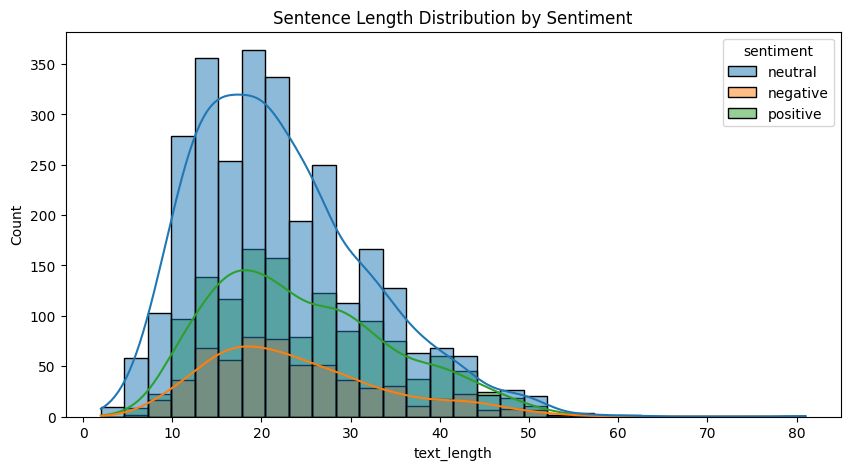

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="text_length", hue="sentiment", bins=30, kde=True)
plt.title("Sentence Length Distribution by Sentiment")
plt.show()

In [12]:
from collections import Counter

In [13]:
for label in df["sentiment"].unique():
    words = " ".join(df[df["sentiment"] == label]["text"]).lower().split()
    common = Counter(words).most_common(15)
    print(f"\n--- {label} ---")
    print(common)


--- neutral ---
[('the', 3720), (',', 2892), ('.', 2838), ('of', 1922), ('and', 1717), ('in', 1527), ('to', 1228), ('a', 962), ('is', 725), ('for', 625), ('will', 595), ("'s", 579), ('company', 508), ('on', 435), ('be', 402)]

--- negative ---
[('the', 759), ('.', 594), (',', 510), ('in', 473), ('of', 440), ('to', 363), ('eur', 325), ('a', 228), ('mn', 224), ('from', 208), ('and', 197), ('profit', 156), ('for', 139), ("'s", 108), ('net', 104)]

--- positive ---
[('the', 1587), ('.', 1348), (',', 1260), ('in', 969), ('to', 918), ('of', 851), ('and', 679), ('a', 524), ('eur', 449), ('for', 387), ('from', 358), ("'s", 313), ('its', 257), ('mn', 241), ('company', 240)]


In [14]:
df.groupby('sentiment')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,604.0,23.917219,9.887414,5.0,17.0,22.0,30.0,56.0
neutral,2879.0,22.176450,9.815893,2.0,15.0,21.0,28.0,81.0
positive,1363.0,24.692590,10.062878,5.0,17.0,23.0,31.0,57.0


In [15]:
import nltk

In [16]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to C:\Users\ARYAN
[nltk_data]     DASH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\ARYAN
[nltk_data]     DASH\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to C:\Users\ARYAN
[nltk_data]     DASH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\ARYAN
[nltk_data]     DASH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [18]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [25]:
def clean_text(text):
    text = text.lower()
    text = text.replace('-', ' ')  
    text = re.sub(r'[^a-z0-9.\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w.strip('.') for w in tokens]
    tokens = [w for w in tokens if w]
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

In [26]:
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(10)

,text,clean_text
0,"According to Gran , the company has no plans t...",according gran company plan move production ru...
1,Technopolis plans to develop in stages an area...,technopolis plan develop stage area less 10000...
2,The international electronic industry company ...,international electronic industry company elco...
3,With the new production plant the company woul...,new production plant company would increase ca...
4,According to the company 's updated strategy f...,according company updated strategy year 2009 2...
5,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,financing aspocomp growth aspocomp aggressivel...
6,"For the last quarter of 2010 , Componenta 's n...",last quarter 2010 componenta net sale doubled ...
7,"In the third quarter of 2010 , net sales incre...",third quarter 2010 net sale increased 5.2 eur ...
8,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur 13.1 mn eur 8.7 mn c...
9,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur 21.1 mn eur 18.6...


In [27]:
print(df.loc[4, "text"])
print(df.loc[4, "clean_text"])

According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .
according company updated strategy year 2009 2012 basware target long term net sale growth range 20 40 operating profit margin 10 20 net sale
